# Import Required Libraries
Import the necessary libraries, including pandas and NumPy.

In [2]:
# Import necessary libraries
import pandas as pd  # Import pandas library and alias it as pd
import numpy as np  # Import NumPy library and alias it as np

In [5]:
# Read CSV file from URL
url = "https://raw.githubusercontent.com/microsoft/ML-For-Beginners/main/2-Regression/data/US-pumpkins.csv"
full_pumpkins = pd.read_csv(url)

full_pumpkins.head()  # Show first 5 rows of the dataframe

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [6]:
columns_to_select = ["City Name", "Package", "Variety", "Origin", "Item Size", "Color"]
pumpkins = full_pumpkins.loc[:, columns_to_select]

pumpkins.dropna(inplace=True)

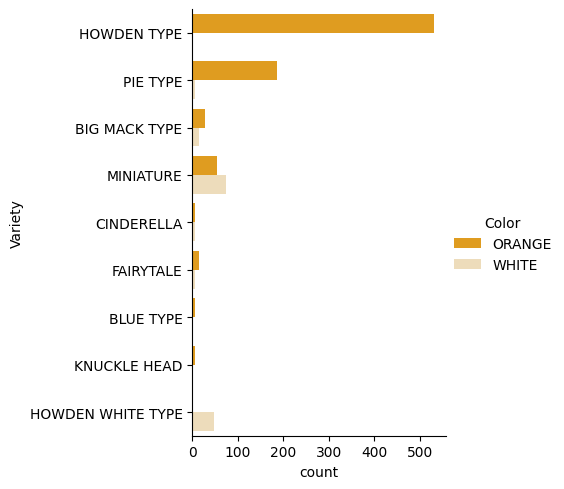

In [9]:
# Plot distribution of varieties and colors
import seaborn as sns

palette = {
    "ORANGE": "orange",
    "WHITE": "wheat",
}

sns.catplot(
    data=pumpkins,
    y="Variety",
    hue="Color",
    kind="count",
    palette=palette,
)

In [10]:
# Display the first five rows of our cleaned dataset
pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


In [11]:
# Turn categorical data into numerical data using one-hot encoding.
#
# The output should be a dense array (regular numpy array) instead of a sparse
# matrix, making it easier to work with and converting with pandas DataFrames.
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["City Name", "Package", "Variety", "Origin"]
categorical_encoder = OneHotEncoder(sparse_output=False)

In [19]:
from sklearn.preprocessing import OrdinalEncoder

item_sizes_categories = ["sml", "med", "med-lge", "lge", "xlge", "jbo", "exjbo"]
ordinal_features = ["Item Size"]
ordinal_encoder = OrdinalEncoder(categories=[item_sizes_categories])

In [20]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_features),
        ("cat", categorical_encoder, categorical_features),
    ]
)

ct.set_output(transform="pandas")
encoded_feautures = ct.fit_transform(pumpkins)

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(pumpkins["Color"])
encoded_pumpkins = encoded_feautures.assign(Color=encoded_label)

In [22]:
from sklearn.model_selection import train_test_split

X = encoded_pumpkins[encoded_pumpkins.columns.difference(["Color"])]
y = encoded_pumpkins["Color"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [23]:
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print("Predicted labels: ", predictions)
print("F1-score: ", f1_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1]
F1-score:  0.7457627118644068
